# EJEMPLO DE PROYECTO FINAL - MODELO REGRESIÓN
# AUTOR: César Mayta
# DATASET : https://www.kaggle.com/datasets/adilshamim8/salaries-for-data-science-jobs

# PASO 1 INSTALAMOS LIBRERIAS

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [4]:
df = pd.read_csv('/content/salary_data_transformed.csv')
df

,company_size,empleado_africa,empleado_asia,empleado_europe,empleado_latin_america,empleado_north_america,empleado_oceania,tipo_ct,tipo_ft,tipo_pt,...,seniority_mi,seniority_se,empleador_africa,empleador_asia,empleador_europe,empleador_latin_america,empleador_north_america,empleador_oceania,salary,remote_ratio
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,348516.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,232344.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,145400.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,81600.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,160000.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39021,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,190000.0,100.0
39022,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,132000.0,100.0
39023,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,166000.0,0.0
39024,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,104000.0,0.0


# PASO 3 - ANALISIS EXPLORATORIO DE DATOS

In [5]:
# tipos de datos
df.dtypes.value_counts()

,count
float64,27


In [6]:
df.dtypes

,0
company_size,float64
empleado_africa,float64
empleado_asia,float64
empleado_europe,float64
empleado_latin_america,float64
empleado_north_america,float64
empleado_oceania,float64
tipo_ct,float64
tipo_ft,float64
tipo_pt,float64


# VERIFICAMOS VALORES NULOS

In [7]:
df.isna().sum()

,0
company_size,0
empleado_africa,0
empleado_asia,0
empleado_europe,0
empleado_latin_america,0
empleado_north_america,0
empleado_oceania,0
tipo_ct,0
tipo_ft,0
tipo_pt,0


In [8]:
df.dtypes

,0
company_size,float64
empleado_africa,float64
empleado_asia,float64
empleado_europe,float64
empleado_latin_america,float64
empleado_north_america,float64
empleado_oceania,float64
tipo_ct,float64
tipo_ft,float64
tipo_pt,float64


## SELECCIONAMOS SOLO LOS VALORES NÚMERICOS

In [59]:
df_clean = df.select_dtypes(include='number').copy()
df_clean

,company_size,empleado_africa,empleado_asia,empleado_europe,empleado_latin_america,empleado_north_america,empleado_oceania,tipo_ct,tipo_ft,tipo_pt,...,seniority_mi,seniority_se,empleador_africa,empleador_asia,empleador_europe,empleador_latin_america,empleador_north_america,empleador_oceania,salary,remote_ratio
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,348516.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,232344.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,145400.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,81600.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,160000.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39021,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,190000.0,100.0
39022,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,132000.0,100.0
39023,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,166000.0,0.0
39024,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,104000.0,0.0


## CORRELACIONES

In [60]:
correlations = df_clean.corr(numeric_only=True)['salary'].sort_values(ascending=False)
display(correlations)

,salary
salary,1.000000
empleado_north_america,0.275227
empleador_north_america,0.274708
seniority_se,0.233695
position_software_engineer,0.167818
seniority_ex,0.117123
tipo_ft,0.068563
position_data_scientist,0.049391
remote_ratio,-0.022534
company_size,-0.027976


# PASO 4  ENTRENAMIENTO DEL MODELO

# MODELOS A USAR
Regresión Lineal → modelo básico para valores continuos.

Ridge → similar a la lineal pero con regularización L2 (reduce sobreajuste).

Lasso → similar a la lineal pero con regularización L1 (puede eliminar variables poco relevantes).

Gradient Boosting → modelo basado en boosting, construye árboles secuenciales para mejorar predicciones.

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

## DEFINIMOS VARIABLE X Y Y

In [62]:
X = df_processed.drop('salary', axis=1)
y = df_processed['salary']

# DIVIDIR DATASET EN ENTRENAMIENTO Y PRUEBA

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

# ESCALAMIENTO DE DATOS

In [64]:
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test) # Use transform on the test set

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train.values.reshape(-1, 1)) # Reshape y_train
y_test = sc_y.transform(y_test.values.reshape(-1, 1)) # Reshape y_test and use transform

# COMPARAMOS LOS MODELOS

In [65]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=1000, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=1000, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state=42),
    "Red Neuronal (MLP)": MLPRegressor(hidden_layer_sizes=(500, ), activation='relu', solver='adam',
                                        max_iter=500, random_state=42)
}

In [66]:
# Evaluar cada modelo
def evaluar_modelo(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
    print(f'Coeficiente de Determinación (R²): {r2:.4f}')
    return r2

In [67]:
# Comparar modelos
resultados = {}
for nombre, modelo in modelos.items():
    resultados[nombre] = evaluar_modelo(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo = max(resultados, key=resultados.get)
print(f'\nEl mejor modelo es: {mejor_modelo} con un R² de {resultados[mejor_modelo]:.4f}')


Regresión Lineal:
Error Cuadrático Medio (MSE): 0.8308
Coeficiente de Determinación (R²): 0.1501

Ridge:
Error Cuadrático Medio (MSE): 0.8308
Coeficiente de Determinación (R²): 0.1501

Lasso:
Error Cuadrático Medio (MSE): 0.8537
Coeficiente de Determinación (R²): 0.1267


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest:
Error Cuadrático Medio (MSE): 0.8233
Coeficiente de Determinación (R²): 0.1578


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?



Gradient Boosting:
Error Cuadrático Medio (MSE): 0.8232
Coeficiente de Determinación (R²): 0.1579

XGBoost:
Error Cuadrático Medio (MSE): 0.8232
Coeficiente de Determinación (R²): 0.1579


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Red Neuronal (MLP):
Error Cuadrático Medio (MSE): 0.8252
Coeficiente de Determinación (R²): 0.1558

El mejor modelo es: XGBoost con un R² de 0.1579


# GRAFICAMOS RESULTADOS

/tmp/ipython-input-3932890601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')


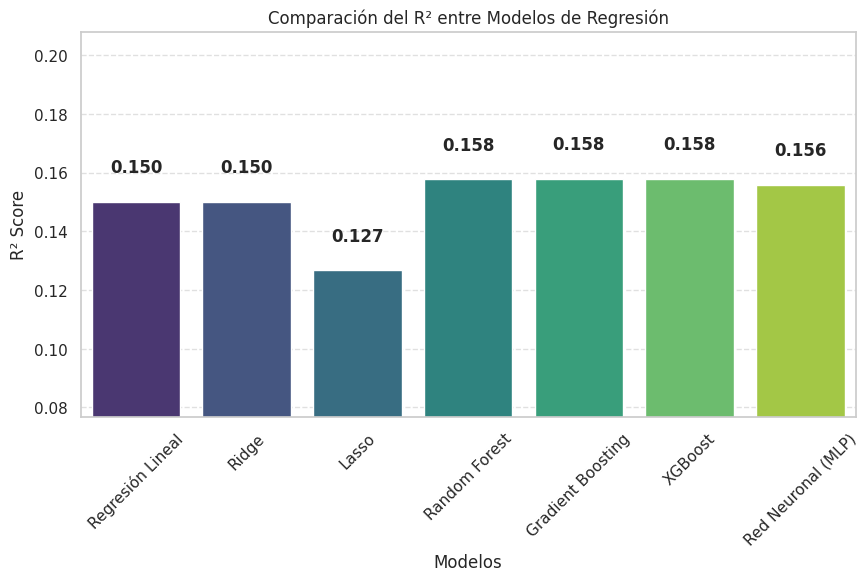

In [68]:
# Mejora en la visualización de la comparación de R²
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')

# Agregar etiquetas de los valores en las barras
for index, value in enumerate(resultados.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

# Ajustar los límites del eje Y para resaltar diferencias
plt.ylim(min(resultados.values()) - 0.05, max(resultados.values()) + 0.05)

plt.xlabel('Modelos')
plt.ylabel('R² Score')
plt.title('Comparación del R² entre Modelos de Regresión')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

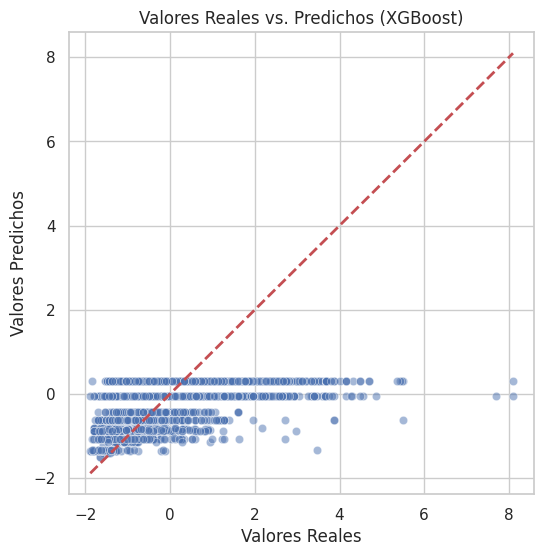

In [69]:
# Evaluación del mejor modelo seleccionado
modelo_seleccionado = modelos[mejor_modelo]
y_pred_mejor = modelo_seleccionado.predict(X_test)

# Gráfico de dispersión entre valores reales y predichos
plt.figure(figsize=(6, 6))
#sns.scatterplot(x=y_test, y=y_pred_mejor, alpha=0.5)
sns.scatterplot(x=np.ravel(y_test), y=np.ravel(y_pred_mejor), alpha=0.5)

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)  # Línea de referencia
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title(f'Valores Reales vs. Predichos ({mejor_modelo})')
plt.show()